# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

**Who?** The primary target audience of the flight delay dataset is individuals responsible for the operations of airlines and airports in the US.

**What?** The goal should be actionable recommendations to improve the flight consistency or safety.

**How?** With the amount of information on delays and accidents as well as thier causes, looking for trends or patterns relating problematic flights to hopefully just a few factors.

# 3. Homework - work with your own data

In [19]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

In [20]:
#Import first dataset, 2015 Flight Delay Data
#Columns 7,8 needed dtype specified directly as infer failed

flights_2015 = pd.read_csv(r"C:\Users\lemrd\Downloads\OMDS\Mod B\Sem 2\Data\2015_Delay_Data\flights.csv", dtype={"DESTINATION_AIRPORT":str, "ORIGIN_AIRPORT":str})

flights_2015.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
flights_2015.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24

In [22]:
flights_2015.describe()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,5819079.0,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.732926e+06,5.732926e+06,5.730032e+06,5.730032e+06,...,5.819079e+06,5.726566e+06,5.714008e+06,5.819079e+06,5.819079e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06
mean,2015.0,6.524085e+00,1.570459e+01,3.926941e+00,2.173093e+03,1.329602e+03,1.335204e+03,9.370158e+00,1.607166e+01,1.357171e+03,...,1.493808e+03,1.476491e+03,4.407057e+00,2.609863e-03,1.544643e-02,1.348057e+01,7.615387e-02,1.896955e+01,2.347284e+01,2.915290e+00
std,0.0,3.405137e+00,8.783425e+00,1.988845e+00,1.757064e+03,4.837518e+02,4.964233e+02,3.708094e+01,8.895574e+00,4.980094e+02,...,5.071647e+02,5.263197e+02,3.927130e+01,5.102012e-02,1.233201e-01,2.800368e+01,2.143460e+00,4.816164e+01,4.319702e+01,2.043334e+01
min,2015.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.200000e+01,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,-8.700000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2015.0,4.000000e+00,8.000000e+00,2.000000e+00,7.300000e+02,9.170000e+02,9.210000e+02,-5.000000e+00,1.100000e+01,9.350000e+02,...,1.110000e+03,1.059000e+03,-1.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2015.0,7.000000e+00,1.600000e+01,4.000000e+00,1.690000e+03,1.325000e+03,1.330000e+03,-2.000000e+00,1.400000e+01,1.343000e+03,...,1.520000e+03,1.512000e+03,-5.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,2.000000e+00,3.000000e+00,0.000000e+00
75%,2015.0,9.000000e+00,2.300000e+01,6.000000e+00,3.230000e+03,1.730000e+03,1.740000e+03,7.000000e+00,1.900000e+01,1.754000e+03,...,1.918000e+03,1.917000e+03,8.000000e+00,0.000000e+00,0.000000e+00,1.800000e+01,0.000000e+00,1.900000e+01,2.900000e+01,0.000000e+00
max,2015.0,1.200000e+01,3.100000e+01,7.000000e+00,9.855000e+03,2.359000e+03,2.400000e+03,1.988000e+03,2.250000e+02,2.400000e+03,...,2.400000e+03,2.400000e+03,1.971000e+03,1.000000e+00,1.000000e+00,1.134000e+03,5.730000e+02,1.971000e+03,1.331000e+03,1.211000e+03


In [23]:
#Before I go any further with this dataset there are a ton of missing values in the final 5 columns. 
#That is because they track how much of the delay was caused by each of 5 factors. 
#If a flight was not delayed, it will have no data in those columns
#All of those missing values should be replaced with zeroes

flights_2015.fillna({"AIR_SYSTEM_DELAY":0,"SECURITY_DELAY":0,"AIRLINE_DELAY":0,"LATE_AIRCRAFT_DELAY":0,"WEATHER_DELAY":0}, inplace=True)
flights_2015.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,0.0,0.0,0.0,0.0,0.0
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,0.0,0.0,0.0,0.0,0.0
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,0.0,0.0,0.0,0.0,0.0
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,0.0,0.0,0.0,0.0,0.0
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,0.0,0.0,0.0,0.0,0.0


In [24]:
#Example of the next problematic bit of missing data
#Canceled flights have many data points missing for obvious reasons
#I am not sure how I will be handling these yet, especially since you can filter them out by the "CANCELLED" column

flights_2015.iloc[32]

YEAR                     2015
MONTH                       1
DAY                         1
DAY_OF_WEEK                 4
AIRLINE                    AS
FLIGHT_NUMBER             136
TAIL_NUMBER            N431AS
ORIGIN_AIRPORT            ANC
DESTINATION_AIRPORT       SEA
SCHEDULED_DEPARTURE       135
DEPARTURE_TIME            NaN
DEPARTURE_DELAY           NaN
TAXI_OUT                  NaN
WHEELS_OFF                NaN
SCHEDULED_TIME          205.0
ELAPSED_TIME              NaN
AIR_TIME                  NaN
DISTANCE                 1448
WHEELS_ON                 NaN
TAXI_IN                   NaN
SCHEDULED_ARRIVAL         600
ARRIVAL_TIME              NaN
ARRIVAL_DELAY             NaN
DIVERTED                    0
CANCELLED                   1
CANCELLATION_REASON         A
AIR_SYSTEM_DELAY          0.0
SECURITY_DELAY            0.0
AIRLINE_DELAY             0.0
LATE_AIRCRAFT_DELAY       0.0
WEATHER_DELAY             0.0
Name: 32, dtype: object

In [25]:
flights_2015.duplicated().any(axis=0)

np.False_

In [26]:
#Import second dataset, 2019 Flight Delay Data

delays_2019 = pd.read_csv(r"C:\Users\lemrd\Downloads\OMDS\Mod B\Sem 2\Data\2019_Delay_Data\full_data_flightdelay.csv")

delays_2019.head()

,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,...,PLANE_AGE,DEPARTING_AIRPORT,LATITUDE,LONGITUDE,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND
0,1,7,0,0800-0859,2,1,25,143,Southwest Airlines Co.,13056,...,8,McCarran International,36.08,-115.152,NONE,0.0,0.0,0.0,65.0,2.91
1,1,7,0,0700-0759,7,1,29,191,Delta Air Lines Inc.,13056,...,3,McCarran International,36.08,-115.152,NONE,0.0,0.0,0.0,65.0,2.91
2,1,7,0,0600-0659,7,1,27,199,Delta Air Lines Inc.,13056,...,18,McCarran International,36.08,-115.152,NONE,0.0,0.0,0.0,65.0,2.91
3,1,7,0,0600-0659,9,1,27,180,Delta Air Lines Inc.,13056,...,2,McCarran International,36.08,-115.152,NONE,0.0,0.0,0.0,65.0,2.91
4,1,7,0,0001-0559,7,1,10,182,Spirit Air Lines,13056,...,1,McCarran International,36.08,-115.152,NONE,0.0,0.0,0.0,65.0,2.91


Immediately it stands out to me that this dataset recorded the carrier names (i.e. airlines) and the airport names completely differently from the last set. 

In [27]:
delays_2019.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6489062 entries, 0 to 6489061
Data columns (total 26 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   MONTH                          int64  
 1   DAY_OF_WEEK                    int64  
 2   DEP_DEL15                      int64  
 3   DEP_TIME_BLK                   object 
 4   DISTANCE_GROUP                 int64  
 5   SEGMENT_NUMBER                 int64  
 6   CONCURRENT_FLIGHTS             int64  
 7   NUMBER_OF_SEATS                int64  
 8   CARRIER_NAME                   object 
 9   AIRPORT_FLIGHTS_MONTH          int64  
 10  AIRLINE_FLIGHTS_MONTH          int64  
 11  AIRLINE_AIRPORT_FLIGHTS_MONTH  int64  
 12  AVG_MONTHLY_PASS_AIRPORT       int64  
 13  AVG_MONTHLY_PASS_AIRLINE       int64  
 14  FLT_ATTENDANTS_PER_PASS        float64
 15  GROUND_SERV_PER_PASS           float64
 16  PLANE_AGE                      int64  
 17  DEPARTING_AIRPORT              object 
 18  LA

Reading the documentation of this dataset, the third column "DEP_DEL15" is a binary representing whether or not the flight was delayed by more than 15 minutes. This dataset is structured to create a model predicting that binary value from the remaining columns.

In [32]:
delays_2019.describe()

,MONTH,DAY_OF_WEEK,DEP_DEL15,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,AIRPORT_FLIGHTS_MONTH,AIRLINE_FLIGHTS_MONTH,AIRLINE_AIRPORT_FLIGHTS_MONTH,...,FLT_ATTENDANTS_PER_PASS,GROUND_SERV_PER_PASS,PLANE_AGE,LATITUDE,LONGITUDE,PRCP,SNOW,SNWD,TMAX,AWND
count,6.489062e+06,6.489062e+06,6.489062e+06,6.489062e+06,6.489062e+06,6.489062e+06,6.489062e+06,6.489062e+06,6.489062e+06,6.489062e+06,...,6.489062e+06,6.489062e+06,6.489062e+06,6.489062e+06,6.489062e+06,6.489062e+06,6.489062e+06,6.489062e+06,6.489062e+06,6.489062e+06
mean,6.607062e+00,3.935598e+00,1.891441e-01,3.821102e+00,3.046890e+00,2.783675e+01,1.337397e+02,1.268458e+04,6.296058e+04,3.459251e+03,...,9.753707e-05,1.355612e-04,1.153211e+01,3.670581e+01,-9.425515e+01,1.037063e-01,3.159310e-02,9.152397e-02,7.146846e+01,8.341329e+00
std,3.396853e+00,1.995200e+00,3.916231e-01,2.382233e+00,1.757864e+00,2.151060e+01,4.645213e+01,8.839796e+03,3.438223e+04,4.251139e+03,...,8.644459e-05,4.649970e-05,6.935706e+00,5.500804e+00,1.790952e+01,3.432134e-01,3.170163e-01,7.281285e-01,1.835333e+01,3.607604e+00
min,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,4.400000e+01,1.100000e+03,5.582000e+03,1.000000e+00,...,0.000000e+00,7.134695e-06,0.000000e+00,1.844000e+01,-1.593460e+02,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+01,0.000000e+00
25%,4.000000e+00,2.000000e+00,0.000000e+00,2.000000e+00,2.000000e+00,1.100000e+01,9.000000e+01,5.345000e+03,2.503400e+04,6.540000e+02,...,3.419267e-05,9.889412e-05,5.000000e+00,3.343600e+01,-1.063770e+02,0.000000e+00,0.000000e+00,0.000000e+00,5.900000e+01,5.820000e+00
50%,7.000000e+00,4.000000e+00,0.000000e+00,3.000000e+00,3.000000e+00,2.300000e+01,1.430000e+02,1.156200e+04,7.087800e+04,2.251000e+03,...,6.178236e-05,1.246511e-04,1.200000e+01,3.750500e+01,-8.790600e+01,0.000000e+00,0.000000e+00,0.000000e+00,7.400000e+01,7.830000e+00
75%,1.000000e+01,6.000000e+00,0.000000e+00,5.000000e+00,4.000000e+00,3.900000e+01,1.720000e+02,1.761500e+04,8.631200e+04,4.806000e+03,...,1.441659e-04,1.772872e-04,1.700000e+01,4.077900e+01,-8.093600e+01,2.000000e-02,0.000000e+00,0.000000e+00,8.600000e+01,1.029000e+01
max,1.200000e+01,7.000000e+00,1.000000e+00,1.100000e+01,1.500000e+01,1.090000e+02,3.370000e+02,3.525600e+04,1.177280e+05,2.183700e+04,...,3.484077e-04,2.289855e-04,3.200000e+01,6.116900e+01,-6.600200e+01,1.163000e+01,1.720000e+01,2.520000e+01,1.150000e+02,3.378000e+01


In [28]:
delays_2019.duplicated().any(axis=0)

np.True_

In [29]:
delays_2019.duplicated().value_counts()

False    6460589
True       28473
Name: count, dtype: int64

I was preparing to drop the duplicate entries, but two unique flights could read as duplicates in this table. Only month, day of the week, and time block are recorded for times. A weekly flight would show up four times under that criteria. The more surprising thing to be duplicated exactly would be the weather, but only 4 factors for weather are recorded. Duplicates represent .4% of the data. I would argue that that is entirely plausible.

In [34]:
delay_causes = pd.read_csv(r"C:\Users\lemrd\Downloads\OMDS\Mod B\Sem 2\Data\Flight_Delay_and_Causes_Data\Flight_delay.csv")
                           
delay_causes.head()

,DayOfWeek,Date,DepTime,ArrTime,CRSArrTime,UniqueCarrier,Airline,FlightNum,TailNum,ActualElapsedTime,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,4,03-01-2019,1829,1959,1925,WN,Southwest Airlines Co.,3920,N464WN,90,...,3,10,0,N,0,2,0,0,0,32
1,4,03-01-2019,1937,2037,1940,WN,Southwest Airlines Co.,509,N763SW,240,...,3,7,0,N,0,10,0,0,0,47
2,4,03-01-2019,1644,1845,1725,WN,Southwest Airlines Co.,1333,N334SW,121,...,6,8,0,N,0,8,0,0,0,72
3,4,03-01-2019,1452,1640,1625,WN,Southwest Airlines Co.,675,N286WN,228,...,7,8,0,N,0,3,0,0,0,12
4,4,03-01-2019,1323,1526,1510,WN,Southwest Airlines Co.,4,N674AA,123,...,4,9,0,N,0,0,0,0,0,16


In [35]:
delay_causes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484551 entries, 0 to 484550
Data columns (total 29 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DayOfWeek          484551 non-null  int64 
 1   Date               484551 non-null  object
 2   DepTime            484551 non-null  int64 
 3   ArrTime            484551 non-null  int64 
 4   CRSArrTime         484551 non-null  int64 
 5   UniqueCarrier      484551 non-null  object
 6   Airline            484551 non-null  object
 7   FlightNum          484551 non-null  int64 
 8   TailNum            484551 non-null  object
 9   ActualElapsedTime  484551 non-null  int64 
 10  CRSElapsedTime     484551 non-null  int64 
 11  AirTime            484551 non-null  int64 
 12  ArrDelay           484551 non-null  int64 
 13  DepDelay           484551 non-null  int64 
 14  Origin             484551 non-null  object
 15  Org_Airport        483374 non-null  object
 16  Dest               4

In [41]:
delay_causes["Org_Airport"].isnull().idxmax(axis=0)

17166

In [43]:
delay_causes.iloc[17166]

DayOfWeek                                              2
Date                                          01-01-2019
DepTime                                             1246
ArrTime                                             1319
CRSArrTime                                          1239
UniqueCarrier                                         OO
Airline                            Skywest Airlines Inc.
FlightNum                                           5741
TailNum                                           N218SW
ActualElapsedTime                                     33
CRSElapsedTime                                        37
AirTime                                               20
ArrDelay                                              40
DepDelay                                              44
Origin                                               MOD
Org_Airport                                          NaN
Dest                                                 SFO
Dest_Airport         San Franci

I noticed the "ORG_AIRPORT" column had some missing values. Turns out to not be a problem though as the "Origin" column, which is the three letter airport code has no missing values. In the example above, Modesto city airport was just too small to have its full name recorded.

In [45]:
delay_causes.duplicated().any(axis=0)

np.True_

In [46]:
delay_causes.duplicated().value_counts()

False    484549
True          2
Name: count, dtype: int64

In [48]:
delay_causes.drop_duplicates(keep="first", inplace=True)
len(delay_causes["ActualElapsedTime"])

484549

The next dataset is a Microsoft Access Database about US Aviation Accidents. Essentially, it is a collection of related tables. A number of the tables are just reference tables such as a list of state abbreviations or country abbreviations. Some of the tables seemingly contain no data, such as the "seq_of_events" (sequence of events) table. The multiple tables discussing each incident start with an "ev_id" column, which is the event ID number.

I am not sure how this dataset will fit into my overall analysis. There are very few numeric columns in the database on which it makes sense to do any sort of basic statistics. 

I'm going to import two of the tables below to demonstrate that I can get them into the codespace and show some examples.

In [55]:
accident_narrative = pd.read_excel(r"C:\Users\lemrd\Downloads\OMDS\Mod B\Sem 2\Data\US_Aviation_Accidents_Data\narratives.xlsx")

accident_narrative.head()

,ev_id,Aircraft_Key,narr_accp,narr_accf,narr_cause,narr_inc,lchg_date,lchg_userid
0,20080107X00026,1,"On January 1, 2008, about 1430 Pacific standar...",The pilots were attending a fly-in at the airp...,The departing pilot's inadequate visual lookou...,NaN,2020-09-25 18:05:31,NaN
1,20080107X00026,2,"On January 1, 2008, about 1430 Pacific standar...",The pilots were attending a fly-in at the airp...,The departing pilot's inadequate visual lookout.,NaN,2020-09-25 18:05:31,NaN
2,20080107X00027,1,"On January 3, 2008, approximately 0225 central...","After an uneventful landing at night, the comm...",The line technician's failure to remain clear ...,NaN,2020-09-25 18:04:02,NaN
3,20080109X00036,1,The private pilot was conducting a touch-and-g...,The private pilot was conducting a touch-and-g...,The pilot's failure to maintain directional co...,NaN,2020-09-25 18:05:31,NaN
4,20080111X00038,1,"On January 3, 2008, at 0745 UTC, a Royal Air M...",NaN,NaN,NaN,2020-09-25 18:07:50,NaN


In [56]:
accident_narrative["narr_accf"][0]

'The pilots were attending a fly-in at the airport.  One pilot in a low-wing airplane was landing, and the other pilot in a high-wing airplane was departing.  The runup area for the landing runway is situated at the beginning of the runway so that following a runup, a pilot can depart straight from the runup area onto the runway.  A witness said that the landing pilot had made radio transmissions around the traffic pattern, and then indicated that he was on final approach for landing.  When the landing pilot was on short final, the departing pilot indicated that he was departing.  The witness was flying above the airport and advised the departing pilot that an airplane was landing.  The airplanes collided shortly thereafter.  According to 14 CFR 91.113, Right-of-way rules: Except water operations, "Aircraft, while on final approach to land or while landing, have the right-of-way over other aircraft in flight or operating on the surface, except that they shall not take advantage of this

In [53]:
accident_flight_crews = pd.read_excel(r"C:\Users\lemrd\Downloads\OMDS\Mod B\Sem 2\Data\US_Aviation_Accidents_Data\Flight_Crew.xlsx")

accident_flight_crews.head()

,ev_id,Aircraft_Key,crew_no,crew_category,crew_age,crew_sex,crew_city,crew_res_state,crew_res_country,med_certf,...,lchg_userid,seat_occ_row,infl_rest_inst,infl_rest_depl,child_restraint,med_crtf_limit,mr_faa_med_certf,pilot_flying,available_restraint,restraint_used
0,20080107X00026,1,1,PLT,56.0,M,Novato,CA,USA,CL3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
1,20080107X00026,2,1,PLT,70.0,M,Pioneer,CA,USA,CL3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
2,20080107X00027,1,1,PLT,59.0,M,Conroe,TX,USA,CL2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
3,20080109X00036,1,1,PLT,54.0,F,Gonzales,TX,USA,CL3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
4,20080114X00044,1,1,FLTI,30.0,M,Miami,FL,USA,CL2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN


In [58]:
accident_flight_crews.iloc[0]

ev_id                       20080107X00026
Aircraft_Key                             1
crew_no                                  1
crew_category                          PLT
crew_age                              56.0
crew_sex                                 M
crew_city                           Novato
crew_res_state                          CA
crew_res_country                       USA
med_certf                              CL3
med_crtf_vldty                         WWL
date_lst_med           2007-11-01 00:00:00
crew_rat_endorse                       NaN
crew_inj_level                        NONE
seatbelts_used                         NaN
shldr_harn_used                        NaN
crew_tox_perf                            N
seat_occ_pic                          LEFT
pc_profession                           No
bfr                                    NaN
bfr_date               2007-07-01 00:00:00
ft_as_of                               NaT
lchg_date              2020-09-25 18:05:31
lchg_userid

In [59]:
domestic_data_2024 = pd.read_csv(r"C:\Users\lemrd\Downloads\OMDS\Mod B\Sem 2\Data\T100_Domestic_Market_and_Segment_Data_8942359590531559889.csv")

domestic_data_2024.head()

,OBJECTID,year,origin,enplanements,passengers,departures,arrivals,freight,mail
0,1,2024,01A,17,17,5,5,0,0
1,2,2024,05A,1,1,1,1,0,0
2,3,2024,06A,50,55,67,66,139,0
3,4,2024,09A,41,43,15,15,0,0
4,5,2024,1B1,32,32,7,7,0,0


In [61]:
domestic_data_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1279 entries, 0 to 1278
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   OBJECTID      1279 non-null   int64 
 1   year          1279 non-null   int64 
 2   origin        1279 non-null   object
 3   enplanements  1279 non-null   int64 
 4   passengers    1279 non-null   int64 
 5   departures    1279 non-null   int64 
 6   arrivals      1279 non-null   int64 
 7   freight       1279 non-null   int64 
 8   mail          1279 non-null   int64 
dtypes: int64(8), object(1)
memory usage: 90.1+ KB


In [60]:
domestic_data_2024.describe()

,OBJECTID,year,enplanements,passengers,departures,arrivals,freight,mail
count,1279.000000,1279.0,1.279000e+03,1.279000e+03,1279.000000,1279.000000,1.279000e+03,1.279000e+03
mean,640.000000,2024.0,6.684760e+05,6.719209e+05,6904.981235,6905.782643,2.013557e+07,9.091194e+05
std,369.359807,0.0,3.293231e+06,3.303452e+06,28871.008111,28869.485102,1.710775e+08,1.006291e+07
min,1.000000,2024.0,0.000000e+00,0.000000e+00,1.000000,1.000000,0.000000e+00,0.000000e+00
25%,320.500000,2024.0,1.200000e+01,1.300000e+01,6.000000,6.000000,0.000000e+00,0.000000e+00
50%,640.000000,2024.0,6.610000e+02,9.540000e+02,310.000000,309.000000,9.680000e+02,0.000000e+00
75%,959.500000,2024.0,2.526100e+04,2.626800e+04,1539.000000,1551.000000,8.574100e+04,1.118000e+03
max,1279.000000,2024.0,4.540603e+07,4.547862e+07,345209.000000,345083.000000,3.710072e+09,3.224877e+08


In [62]:
domestic_data_2024.duplicated().any(axis=0)

np.False_

This last dataset is pretty simple with no missing or duplicated data. All of the year columns are the same, all of the origins are unique airports and all of the other columns are integer counts for each airport.

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data. Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

In [30]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

Text(0.5, 1.0, 'Average Retail Product Price per Year')

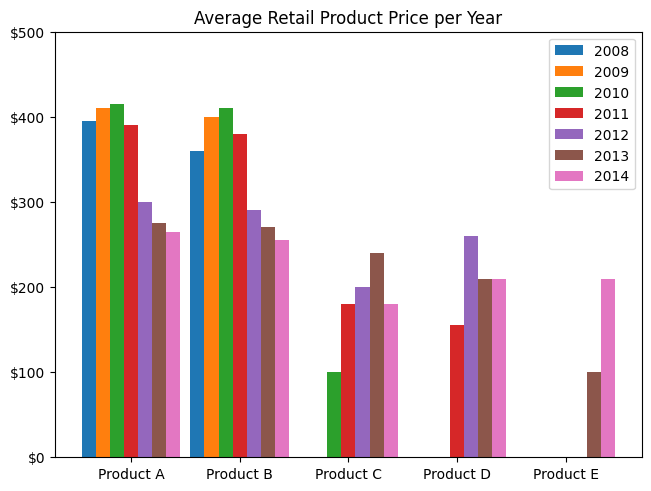

In [31]:
products = ['Product A','Product B','Product C','Product D','Product E']
data = {2008:[395,360,0,0,0],2009:[410,400,0,0,0],2010:[415,410,100,0,0],2011:[390,380,180,155,0],2012:[300,290,200,260,0],2013:[275,270,240,210,100],2014:[265,255,180,210,210]}

x = np.arange(5)
width = .13
i = 0

fig,ax = plt.subplots(layout='constrained')

for year, values in data.items():
    offset = width * i
    rects = ax.bar(x + offset, values, width, label=year)
    i += 1

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
ax.set_xticks(x + 3*width, products)
ax.legend()
ax.set_ylim(0,500)
plt.title('Average Retail Product Price per Year')